<a href="https://colab.research.google.com/github/triaanandafh/Mk_Data-Mining/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/credit_data_sample.csv', sep=';')

#tampilkan 5 data pertama
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Credit_amount,Duration,Employment_since,Purpose
0,25,2000,12,2,car
1,40,7000,48,5,business
2,35,3500,24,4,car
3,23,1200,10,1,furniture
4,52,9000,60,5,real_estate


In [ ]:
features = ['Age', 'Credit_amount', 'Duration', 'Employment_since']
X = df[features]

In [ ]:
# standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

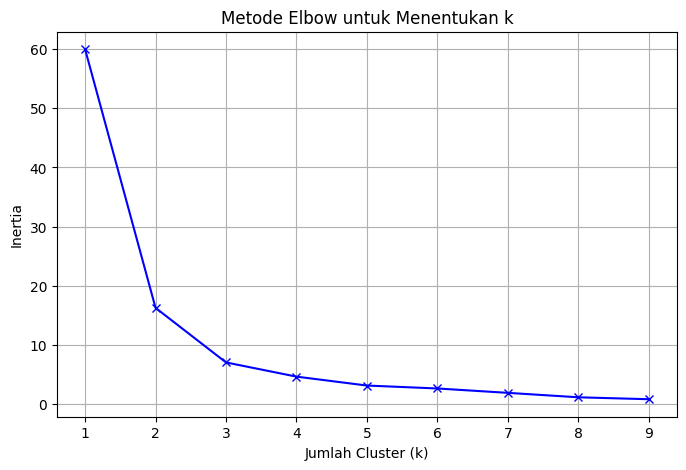

In [ ]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot hasil Elbow
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [ ]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# lihat hasil clustering
df.head()

,Age,Credit_amount,Duration,Employment_since,Purpose,Cluster
0,25,2000,12,2,car,2
1,40,7000,48,5,business,0
2,35,3500,24,4,car,1
3,23,1200,10,1,furniture,2
4,52,9000,60,5,real_estate,0


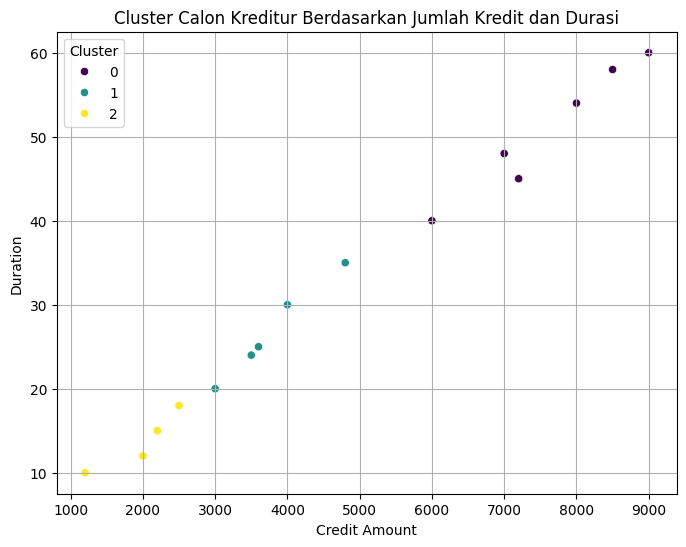

In [ ]:
# Visualisasi hasil clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Credit_amount'],
y=df['Duration'], hue=df['Cluster'],
palette='viridis')
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.grid(True)
plt.show()

Silhoutte Score: 0.549
Inertia (k=3): 7.016


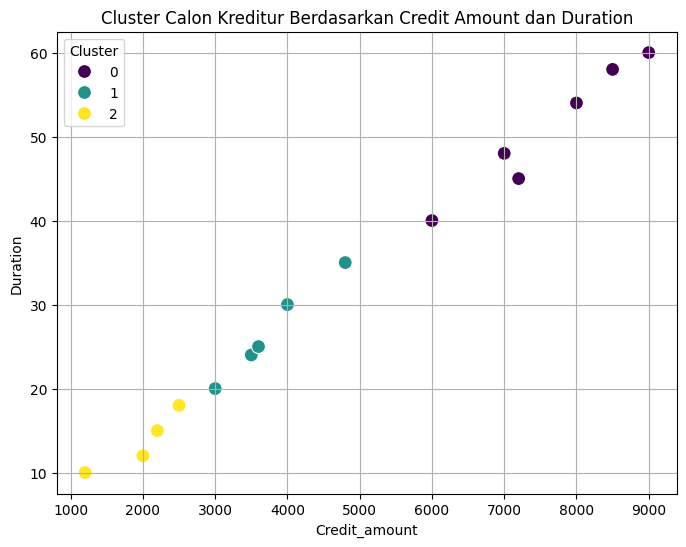

In [ ]:
# 7a. Hitung Silhoutte Score
silhoutte_avg = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhoutte Score: {silhoutte_avg:.3f}')

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Step 8 - Visualisasi hasil clustering (2 fitur: Credit_amount vs Duration)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Credit_amount'],
y=df['Duration'], hue=df['Cluster'],
palette='viridis', s=100)

plt.title('Cluster Calon Kreditur Berdasarkan Credit Amount dan Duration')
plt.xlabel('Credit_amount')
plt.ylabel('Duration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

In [ ]:
# 1. Load Data
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
# 2. Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_iris)

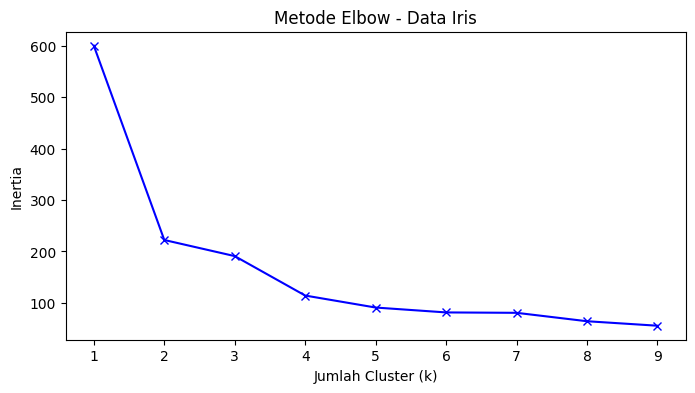

In [ ]:
# 3. Elbow Method untuk menentukan K
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.title('Metode Elbow - Data Iris')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# 4. Membuat Model KMeans (Gunakan k=3 sesuai spesies asli)
kmeans_iris = KMeans(n_clusters=3, random_state=42)
df_iris['Cluster'] = kmeans_iris.fit_predict(X_scaled)

Silhouette Score Iris: 0.480


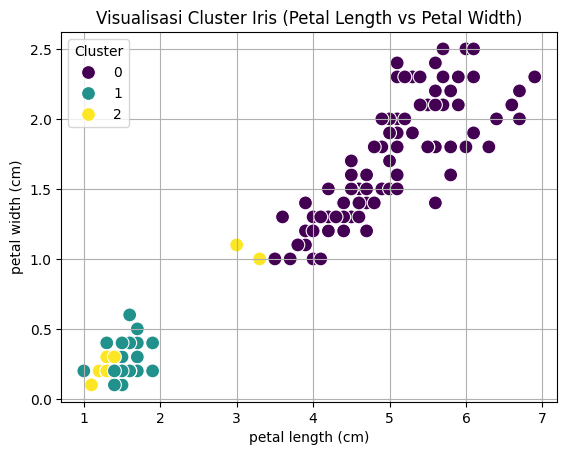

In [ ]:
# 5. Evaluasi & Visualisasi
score = silhouette_score(X_scaled, df_iris['Cluster'])
print(f'Silhouette Score Iris: {score:.3f}')

sns.scatterplot(x=df_iris['petal length (cm)'],
                y=df_iris['petal width (cm)'],
                hue=df_iris['Cluster'],
                palette='viridis', s=100)
plt.title('Visualisasi Cluster Iris (Petal Length vs Petal Width)')
plt.grid(True)
plt.show()

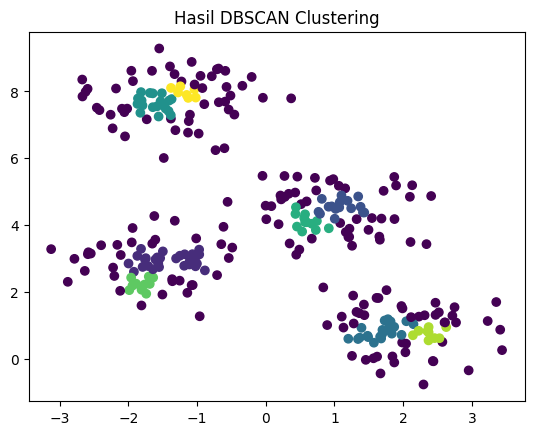

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
# Membuat data contoh
X, _ = make_blobs(n_samples=300, centers=4,
cluster_std=0.60, random_state=0)
# Menggunakan DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
labels = dbscan.fit_predict(X)
# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=labels,
cmap='viridis')
plt.title("Hasil DBSCAN Clustering")
plt.show()

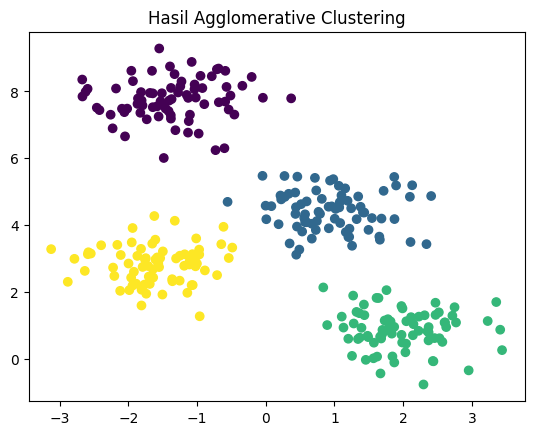

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# Menggunakan Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=4)
agg_labels = agg_clust.fit_predict(X)
# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=agg_labels,
cmap='viridis')
plt.title("Hasil Agglomerative Clustering")
plt.show()

In [ ]:
# 1. Load data
from google.colab import drive
drive.mount('/content/drive')
dk = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/Dataset SIB 2G.csv', sep=',')



Mounted at /content/drive


NameError: name 'pd' is not defined

In [ ]:
dk[features] = dk[features].fillna(dk[features].mean())
dk.head()

,Timestamp,Nama,Tempat Lahir,Tanggal Lahir,Jenis Kelamin,Tinggi Badan (cm),Berat Badan (kg),Kota Asal,Alamat Domisili Saat Ini,Jenis Kendaraan Utama,...,Hobi,Alat Utama Mencatat Saat Kuliah,MBTI (kepribadian),Waktu Produktif/Fokus,Rata - Rata Screen Time HP per Hari (jam),Aplikasi Yang Paling Sering Dibuka di HP,Metode Pembayaran Favorit,Usia (tahun),Jumlah Aplikasi di Hp,Jumlah Device yang Dimiliki
0,2/10/2026 18:47:53,Pratama Angga Saputra,Malang,7/10/2005,Laki-Laki,165.00,52.5000,Malang,Jl. Mergan lori 2b no 51 RT 5 RW 6,Motor,...,Menonton Anime dan Baca Manhwa,Laptop,INFP,Malam,5.5,Webtoon,Cash,20.000,68.0,2.0
1,"2/10/2026 18:55:03,Muchammad Nabil Haykal Wida...",NaN,NaN,NaN,NaN,168.25,58.1875,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.875,NaN,NaN
2,2/10/2026 18:55:51,Moh. Rafael Abrari,Lamongan,11/27/2006,Laki-Laki,173.00,55.0000,Lamongan,jl. kenanga indah,Motor,...,Mancing,Ingatan,Mengaji,Malam,5.0,Instagram,QRIS,19.000,30.0,2.0
3,2/10/2026 19:49:44,Muhamad Miftahul Akmal,Cilegon,3/5/2005,Laki-Laki,168.00,70.0000,Cilegon,Jalan pisang kipas dalam,Motor,...,Tiduran dan bersantai santai,Laptop,INFP,Malam,10.0,Whatsapp,Cash,20.000,10.0,2.0
4,"2/10/2026 19:54:36,Narendra Daniswara Alamsyah...",NaN,NaN,NaN,NaN,168.25,58.1875,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.875,NaN,NaN


In [ ]:
# 2. Seleksi Fitur (Hanya ambil kolom numerik agar tidak error)
features = ['IPK Semester Kemarin', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'Usia (tahun)']
X = dk[features]

In [ ]:
# 3. Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

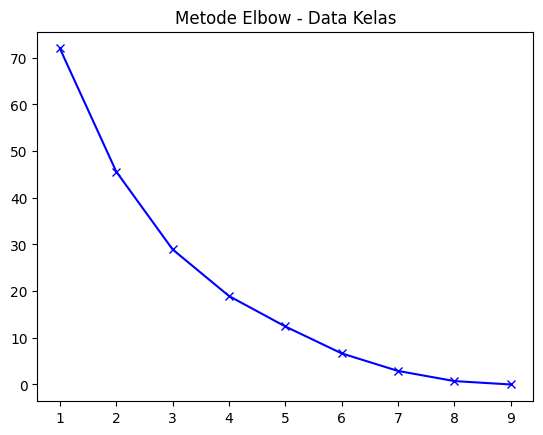

In [ ]:
# 4. Elbow Method
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bx-')
plt.title('Metode Elbow - Data Kelas')
plt.show()

Silhouette Score Data Kelas: 0.523


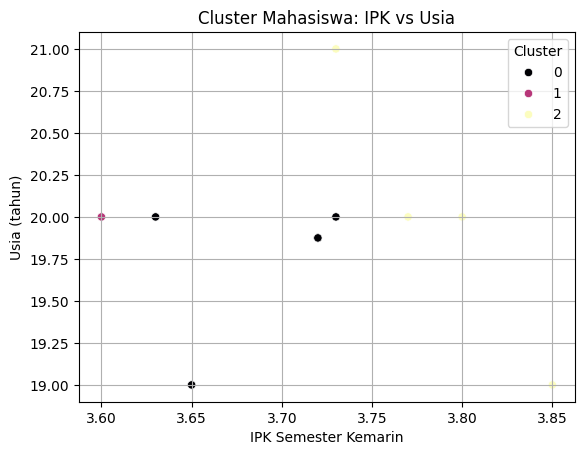

In [ ]:
# 5. Membuat Model KMeans (Coba k=3)
kmeans_kelas = KMeans(n_clusters=3, random_state=42)
dk['Cluster'] = kmeans_kelas.fit_predict(X_scaled)

# 6. Evaluasi & Visualisasi
score_kelas = silhouette_score(X_scaled, dk['Cluster'])
print(f'Silhouette Score Data Kelas: {score_kelas:.3f}')

# Visualisasi (IPK vs Usia sebagai contoh)
sns.scatterplot(x=dk['IPK Semester Kemarin'], y=dk['Usia (tahun)'], hue=dk['Cluster'], palette='magma')
plt.title('Cluster Mahasiswa: IPK vs Usia')
plt.grid(True)
plt.show()